In [54]:
from glob import glob
import os
from pathlib import Path
import pickle

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import xarray as xr

from model_tuner.utils import load_yaml
from model_tuner.main import OptExperimentParams


dirpath_base = Path(
    r'D:\WORK\Salvador\repo\model_tuner\test_data\main'
    r'\test_opt_A1_hpc_batch_qsub\experiments'
    r'\test_2_pfr=(0.4_1.0_4)_wmult=0.005_alpha=1'
)

# Load experiment params
fpath_exp_params = dirpath_base / 'exp_params.yaml'
exp_params = load_yaml(fpath_exp_params,
                          data_class=OptExperimentParams)

# Load target firing rates
df_target_rates = pd.read_csv(dirpath_base / 'target_rates.csv')
target_rates = dict(zip(df_target_rates['pop_name'],
                        df_target_rates['target_rate']))

pop_names = list(exp_params.pop_names)
pfr_vec = exp_params.pfr_vec

n_pop = len(pop_names)
n_pfr = len(pfr_vec)

fpath_mask = str(dirpath_base / 'info' / f'Ru_Rc_req_*.pkl')
n_iter = len(glob(fpath_mask))

# Create xarray dataset to store Ru and Rc matrices
X = xr.Dataset(
    {
        "Ru": (["pop", "iter", "pfr"], np.full((n_pop, n_iter, n_pfr), np.nan)),
        "Rc": (["pop", "iter", "pfr"], np.full((n_pop, n_iter, n_pfr), np.nan)),
        "Rc_mat_mixed": (["pop", "iter", "pfr"], np.full((n_pop, n_iter, n_pfr), np.nan)),
    },
    coords={"pop": pop_names, "iter": range(n_iter), "pfr": pfr_vec},
)

# Load Ru and Rc matrices
iter_data = {}
for n in range(n_iter):
    fpath_mask = str(dirpath_base / 'info' / f'Ru_Rc_req_{n}_*.pkl')
    fpath_iter_data = glob(fpath_mask)[0]
    with open(fpath_iter_data, 'rb') as f:
        iter_data = pickle.load(f)
    coords_ = {'pop': pop_names, 'pfr': iter_data['pfr']}
    for data_type in ('Ru', 'Rc', 'Rc_mat_mixed'):
        X[data_type].loc[{'iter': n, 'pfr': Ru_.pfr}] = (
            xr.DataArray(iter_data[data_type], dims=['pop', 'pfr'], coords=coords_)
        )

In [25]:
# Convert target rate dict to xarray
Rc0 = xr.DataArray(
    list(target_rates.values()), dims=['pop'], coords={'pop': pop_names}
)

In [48]:
pfr_vec

array([0.4, 0.6, 0.8, 1. ])

Text(0.5, 1.0, 'Angle with the target rate vector')

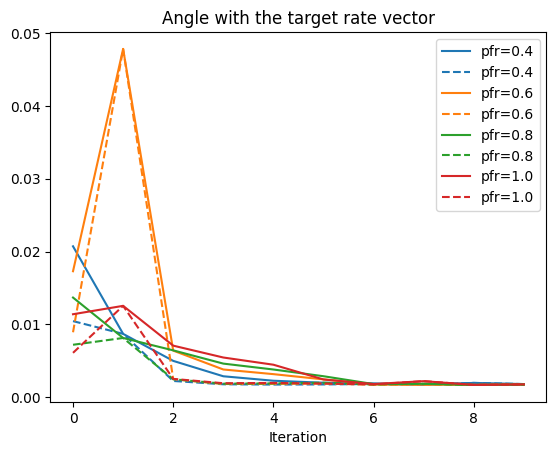

In [63]:
import matplotlib.pyplot as plt
from numpy.linalg import norm

rc0 = Rc0.values
rc0_norm = rc0 / norm(rc0)

def_colors = plt.rcParams['axes.prop_cycle'].by_key()['color'][:4]
styles = ['-', '--']

plt.figure()
for pfr_num, pfr in enumerate(pfr_vec):
    for data_num, data_type in enumerate(['Rc', 'Rc_mat_mixed']):

        qvec = np.zeros(n_iter)
        for n in range(n_iter):
            rc = X[data_type].sel(iter=n).isel(pfr=pfr_num).values
            rc_norm = rc / norm(rc)
            qvec[n] = np.dot(rc_norm, rc0_norm)

        plt.plot(
            -np.log(qvec),
            styles[data_num],
            #label=data_type
            label=f'pfr={pfr}',
            color=def_colors[pfr_num],
        )

plt.legend()
plt.xlabel('Iteration')
plt.title('Angle with the target rate vector')